# 02 — EDA on `data/processed/`

Visual exploration of the YOLO dataset **after** the data-processing pipeline.
Read-only: does not write or modify `raw/`, `interim/`, or `processed/`.

Prerequisite: run `uv run python scripts/process_data.py` (or `01_data_processing.ipynb`) first.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image

from vpc2.data import io

ROOT = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
SPLITS = ("train", "val", "test")

yaml_path = PROCESSED / "data.yaml"
if not yaml_path.is_file():
    raise FileNotFoundError(
        f"Missing {yaml_path}. Run first: uv run python scripts/process_data.py"
    )

payload = io.load_yolo_yaml(yaml_path)
CLASS_NAMES = io.class_names_from_yaml(payload)
print("processed:", PROCESSED)
print(f"classes ({len(CLASS_NAMES)}): {CLASS_NAMES}")

processed: D:\CEIA\B4\VPC2_TP\data\processed
classes (6): ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']


## Inventory: images, labels, and boxes

For detection, **instances** (boxes) matter more than images per folder.

In [4]:
def parse_boxes(label_path: Path) -> list[tuple[int, float, float, float, float]]:
    boxes = []
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.split()
        if len(parts) < 5:
            continue
        class_id = int(float(parts[0]))
        x, y, w, h = (float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4]))
        boxes.append((class_id, x, y, w, h))
    return boxes


rows = []
for split in SPLITS:
    images = io.list_images(PROCESSED / "images" / split)
    for image_path in images:
        label_path = io.matching_label_path(image_path, PROCESSED / "labels" / split)
        boxes = parse_boxes(label_path) if label_path.is_file() else []
        rows.append((split, image_path, label_path, boxes))

image_counts = Counter(split for split, *_ in rows)
box_counts = Counter()
box_counts_by_split = defaultdict(Counter)
images_with_class = defaultdict(Counter)
boxes_per_image = []
widths, heights, areas = [], [], []
formats = Counter()
resolutions = Counter()

for split, image_path, _label_path, boxes in rows:
    boxes_per_image.append(len(boxes))
    present = {box[0] for box in boxes}
    for class_id, _x, _y, w, h in boxes:
        box_counts[class_id] += 1
        box_counts_by_split[split][class_id] += 1
        widths.append(w)
        heights.append(h)
        areas.append(w * h)
    for class_id in present:
        images_with_class[split][class_id] += 1
    formats[image_path.suffix.lower()] += 1

sample_for_res = rows[: min(400, len(rows))]
for _split, image_path, _label_path, _boxes in sample_for_res:
    with Image.open(image_path) as image:
        resolutions[image.size] += 1

print("images per split:", dict(image_counts))
print("total images:", sum(image_counts.values()))
print("total boxes:", sum(box_counts.values()))
print("boxes per class:")
for class_id, name in enumerate(CLASS_NAMES):
    print(f"  {class_id} {name}: {box_counts[class_id]}")
print("formats:", dict(formats))
print("resolutions (sample):", resolutions.most_common(5))

images per split: {'train': 7326, 'val': 2093, 'test': 1045}
total images: 10464
total boxes: 74073
boxes per class:
  0 BIODEGRADABLE: 45395
  1 CARDBOARD: 4696
  2 GLASS: 7809
  3 METAL: 5841
  4 PAPER: 4387
  5 PLASTIC: 5945
formats: {'.jpg': 10464}
resolutions (sample): [((416, 416), 400)]


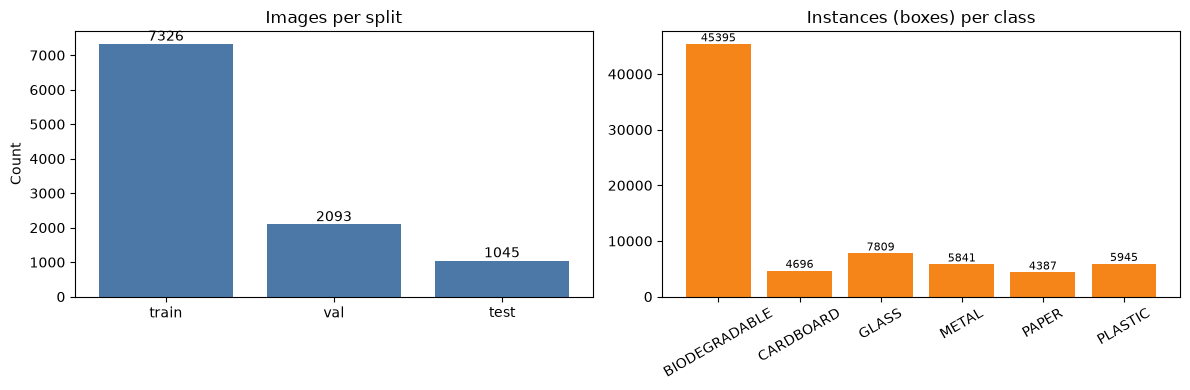

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(SPLITS, [image_counts[split] for split in SPLITS], color="#4C78A8")
axes[0].set_title("Images per split")
axes[0].set_ylabel("Count")
for i, split in enumerate(SPLITS):
    axes[0].text(i, image_counts[split], str(image_counts[split]), ha="center", va="bottom")

names = CLASS_NAMES
values = [box_counts[i] for i in range(len(names))]
axes[1].bar(names, values, color="#F58518")
axes[1].set_title("Instances (boxes) per class")
axes[1].tick_params(axis="x", rotation=30)
for i, value in enumerate(values):
    axes[1].text(i, value, str(value), ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()

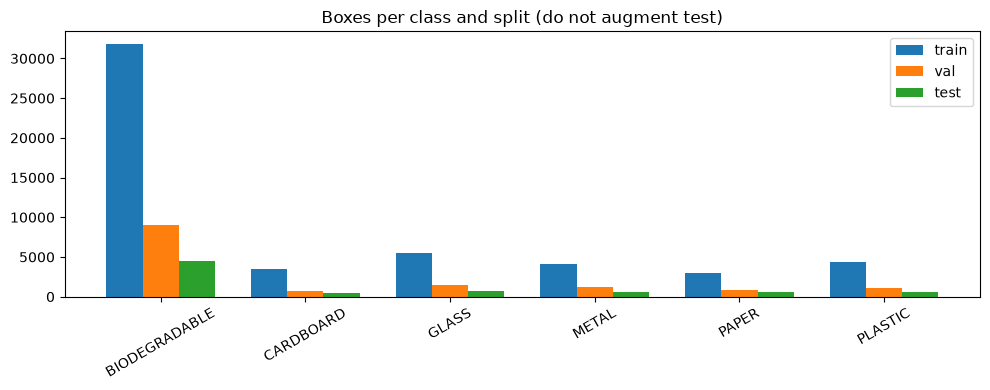

Images containing at least one box of each class:
  BIODEGRADABLE: train=1605, val=454, test=228
  CARDBOARD: train=1058, val=298, test=146
  GLASS: train=1883, val=531, test=270
  METAL: train=1357, val=363, test=178
  PAPER: train=1237, val=356, test=175
  PLASTIC: train=1005, val=301, test=158


In [6]:
x = np.arange(len(CLASS_NAMES))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 4))
for i, split in enumerate(SPLITS):
    counts = [box_counts_by_split[split][class_id] for class_id in range(len(CLASS_NAMES))]
    ax.bar(x + (i - 1) * width, counts, width, label=split)
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=30)
ax.set_title("Boxes per class and split (do not augment test)")
ax.legend()
fig.tight_layout()
plt.show()

print("Images containing at least one box of each class:")
for class_id, name in enumerate(CLASS_NAMES):
    parts = [f"{split}={images_with_class[split][class_id]}" for split in SPLITS]
    print(f"  {name}: {', '.join(parts)}")

## Samples with bounding boxes

One train image per class (the first that contains that class).

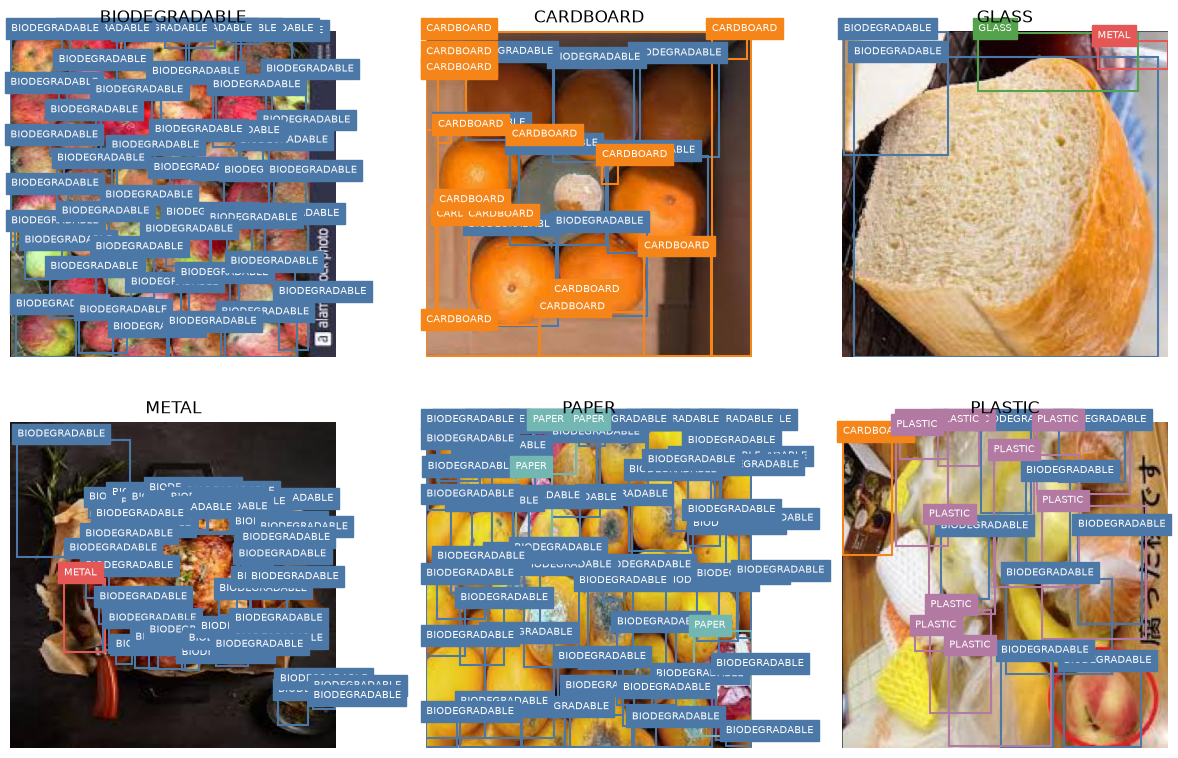

In [7]:
COLORS = [
    "#4C78A8",
    "#F58518",
    "#54A24B",
    "#E45756",
    "#72B7B2",
    "#B279A2",
]


def draw_boxes(ax, image, boxes, class_names):
    height, width = image.shape[:2]
    ax.imshow(image)
    for class_id, xc, yc, bw, bh in boxes:
        x1 = (xc - bw / 2.0) * width
        y1 = (yc - bh / 2.0) * height
        color = COLORS[class_id % len(COLORS)]
        ax.add_patch(
            Rectangle(
                (x1, y1),
                bw * width,
                bh * height,
                fill=False,
                edgecolor=color,
                linewidth=1.5,
            )
        )
        label = class_names[class_id] if class_id < len(class_names) else str(class_id)
        ax.text(x1, max(y1 - 4, 0), label, color="white", fontsize=7, backgroundcolor=color)
    ax.axis("off")


samples = {}
for split, image_path, _label_path, boxes in rows:
    if split != "train":
        continue
    for class_id, *_rest in boxes:
        if class_id not in samples:
            samples[class_id] = (image_path, boxes)
    if len(samples) == len(CLASS_NAMES):
        break

ncols = 3
nrows = int(np.ceil(len(CLASS_NAMES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
for class_id, name in enumerate(CLASS_NAMES):
    ax = axes[class_id]
    if class_id not in samples:
        ax.set_title(f"{name}: no sample")
        ax.axis("off")
        continue
    image_path, boxes = samples[class_id]
    image = io.load_image(image_path)
    draw_boxes(ax, image, boxes, CLASS_NAMES)
    ax.set_title(name)
for ax in axes[len(CLASS_NAMES) :]:
    ax.axis("off")
fig.tight_layout()
plt.show()

## Box size and density

Width, height, and area are in normalized YOLO coordinates (`[0, 1]`).

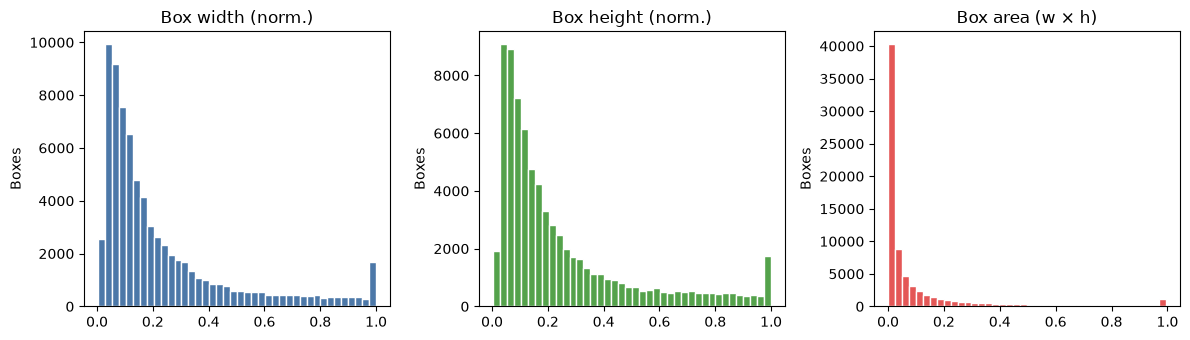

boxes/image: min=1 median=2 mean=7.08 max=358
box area: p10=0.0022 p50=0.0199 p90=0.3021


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].hist(widths, bins=40, color="#4C78A8", edgecolor="white")
axes[0].set_title("Box width (norm.)")
axes[1].hist(heights, bins=40, color="#54A24B", edgecolor="white")
axes[1].set_title("Box height (norm.)")
axes[2].hist(areas, bins=40, color="#E45756", edgecolor="white")
axes[2].set_title("Box area (w × h)")
for ax in axes:
    ax.set_ylabel("Boxes")
fig.tight_layout()
plt.show()

print(
    "boxes/image: "
    f"min={min(boxes_per_image)} median={int(np.median(boxes_per_image))} "
    f"mean={np.mean(boxes_per_image):.2f} max={max(boxes_per_image)}"
)
print(
    "box area: "
    f"p10={np.percentile(areas, 10):.4f} p50={np.percentile(areas, 50):.4f} "
    f"p90={np.percentile(areas, 90):.4f}"
)

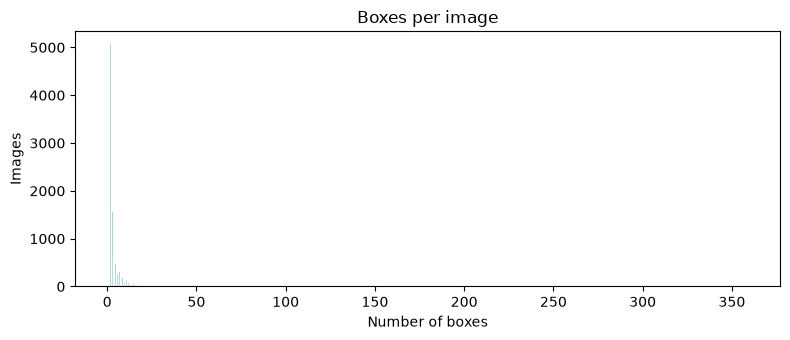

images with no boxes: 0


In [9]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(boxes_per_image, bins=range(0, max(boxes_per_image) + 2), color="#72B7B2", edgecolor="white")
ax.set_title("Boxes per image")
ax.set_xlabel("Number of boxes")
ax.set_ylabel("Images")
fig.tight_layout()
plt.show()

empty = sum(1 for count in boxes_per_image if count == 0)
print(f"images with no boxes: {empty}")

## Resolution and format

Roboflow v2 usually ships a single size. If the histogram is flat, there is no need to drop low-res images (that step was for the Class 2 Pokémon classification notebook).

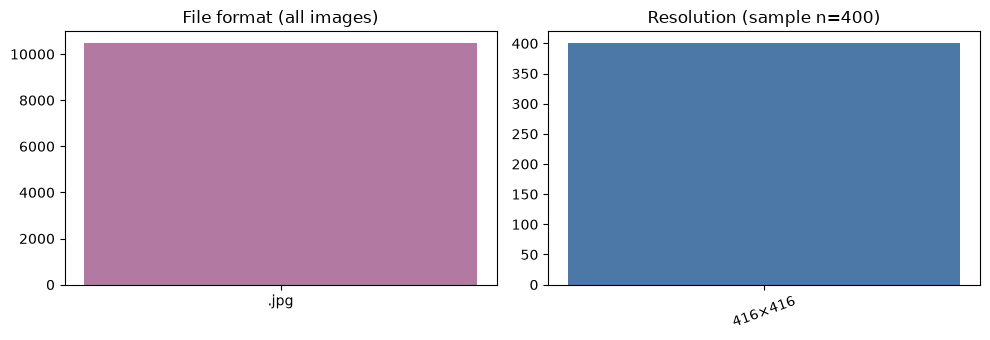

In [10]:
res_labels = [f"{w}×{h}" for (w, h), _count in resolutions.most_common(8)]
res_values = [count for _size, count in resolutions.most_common(8)]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(list(formats.keys()), list(formats.values()), color="#B279A2")
axes[0].set_title("File format (all images)")
axes[1].bar(res_labels, res_values, color="#4C78A8")
axes[1].set_title(f"Resolution (sample n={len(sample_for_res)})")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()

## Notes for the team

- **Alejandro (aug):** the imbalance is in instances, not just images. Do not touch `test/`.
- **Julia (train):** `data/processed/data.yaml` already points to train/val/**held-out test**.